In [19]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/xgboost-smote-detect-fraud/master/data/creditcard.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (56874, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,10,0.385,0.616,-0.874,-0.094,2.925,3.317,0.470,0.538,-0.559,...,0.050,0.238,0.009,0.997,-0.767,-0.492,0.042,-0.054,9.99,0
1,12,-0.752,0.345,2.057,-1.469,-1.158,-0.078,-0.609,0.004,-0.436,...,0.500,1.354,-0.257,-0.065,-0.039,-0.087,-0.181,0.129,15.99,0
2,25,1.114,0.086,0.494,1.336,-0.300,-0.011,-0.119,0.189,0.206,...,-0.053,-0.005,-0.031,0.198,0.565,-0.338,0.029,0.004,4.45,0
3,33,-0.936,0.170,2.746,-1.078,-0.306,0.012,-0.296,0.403,-0.040,...,0.401,1.065,-0.158,0.296,-0.259,0.754,0.047,0.094,9.10,0
4,35,1.199,0.130,0.864,1.003,-0.784,-0.885,-0.041,-0.208,0.392,...,-0.042,0.198,-0.033,1.013,0.559,0.402,-0.006,0.018,0.99,0


In [23]:
print("Class Distribution:")
print(df["Class"].value_counts())
print("\nPercentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Class Distribution:
Class
0    56772
1      102
Name: count, dtype: int64

Percentage:
Class
0    99.820656
1     0.179344
Name: proportion, dtype: float64


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df.drop("Class", axis=1)
y = df["Class"]
scaler = StandardScaler()
X["Amount"] = scaler.fit_transform(X[["Amount"]])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (45499, 30)
Testing data: (11375, 30)


Decision Tree Results
---------------------
Accuracy: 0.9990329670329671

Confusion Matrix:
[[11350     5]
 [    6    14]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11355
           1       0.74      0.70      0.72        20

    accuracy                           1.00     11375
   macro avg       0.87      0.85      0.86     11375
weighted avg       1.00      1.00      1.00     11375



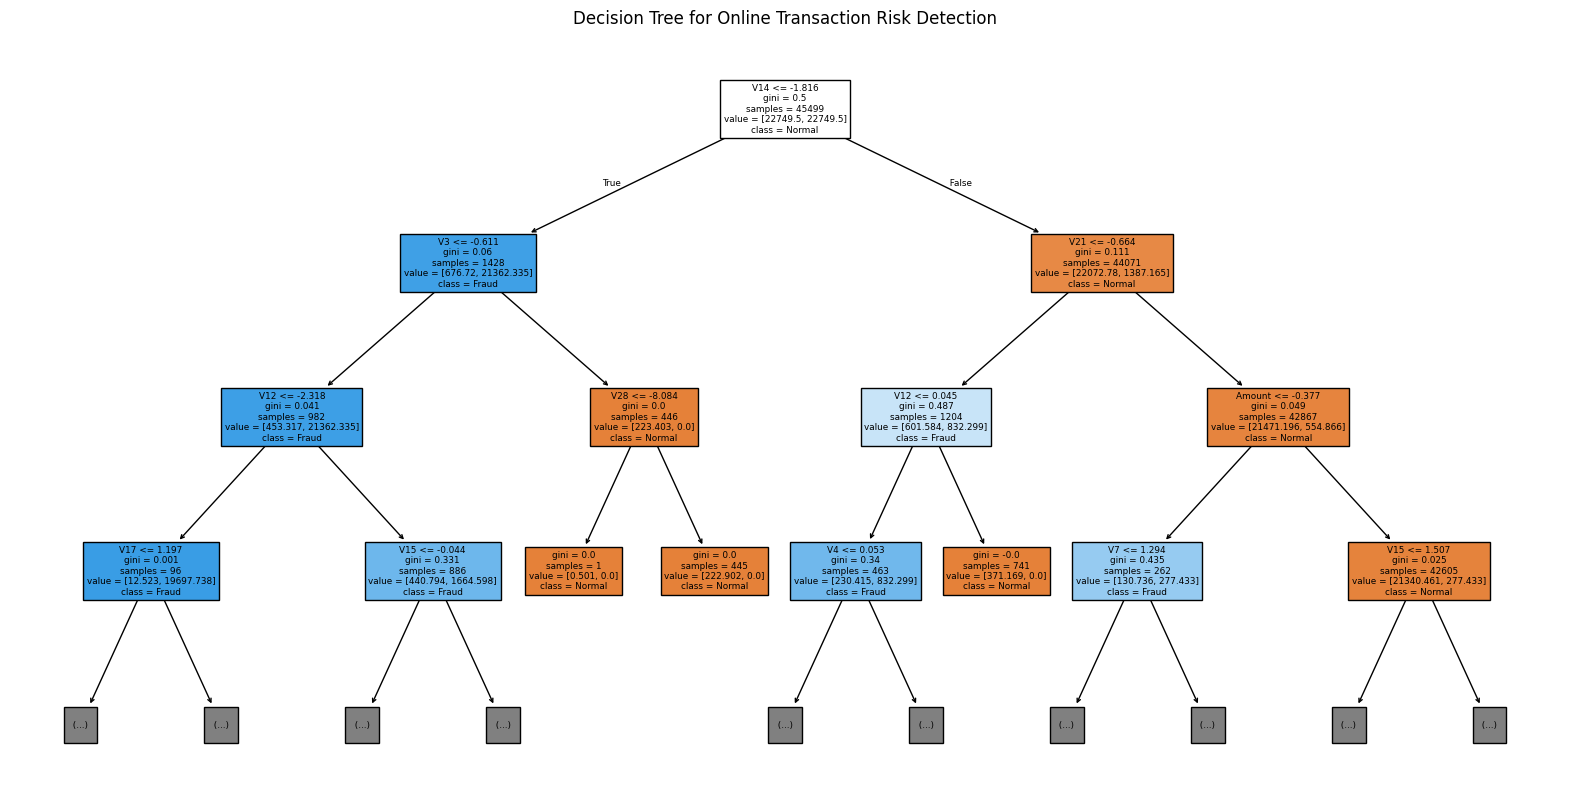

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Normal", "Fraud"],
    filled=True,
    max_depth=3
)
plt.title("Decision Tree for Online Transaction Risk Detection")
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy: 0.9995604395604396

Confusion Matrix:
[[11355     0]
 [    5    15]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11355
           1       1.00      0.75      0.86        20

    accuracy                           1.00     11375
   macro avg       1.00      0.88      0.93     11375
weighted avg       1.00      1.00      1.00     11375



In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score
dt_accuracy = accuracy_score(y_test, y_pred_dt) * 100
dt_precision = precision_score(y_test, y_pred_dt) * 100
dt_recall = recall_score(y_test, y_pred_dt) * 100
dt_f1 = f1_score(y_test, y_pred_dt) * 100
rf_accuracy = accuracy_score(y_test, y_pred_rf) * 100
rf_precision = precision_score(y_test, y_pred_rf) * 100
rf_recall = recall_score(y_test, y_pred_rf) * 100
rf_f1 = f1_score(y_test, y_pred_rf) * 100
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Decision Tree": [
        f"{dt_accuracy:.2f}%",
        f"{dt_precision:.2f}%",
        f"{dt_recall:.2f}%",
        f"{dt_f1:.2f}%"
    ],
    "Random Forest": [
        f"{rf_accuracy:.2f}%",
        f"{rf_precision:.2f}%",
        f"{rf_recall:.2f}%",
        f"{rf_f1:.2f}%"
    ]
})
print("\n========================================")
print("          MODEL COMPARISON")
print("========================================")

display(comparison)


          MODEL COMPARISON


,Metric,Decision Tree,Random Forest
0,Accuracy,99.90%,99.96%
1,Precision,73.68%,100.00%
2,Recall,70.00%,75.00%
3,F1-Score,71.79%,85.71%


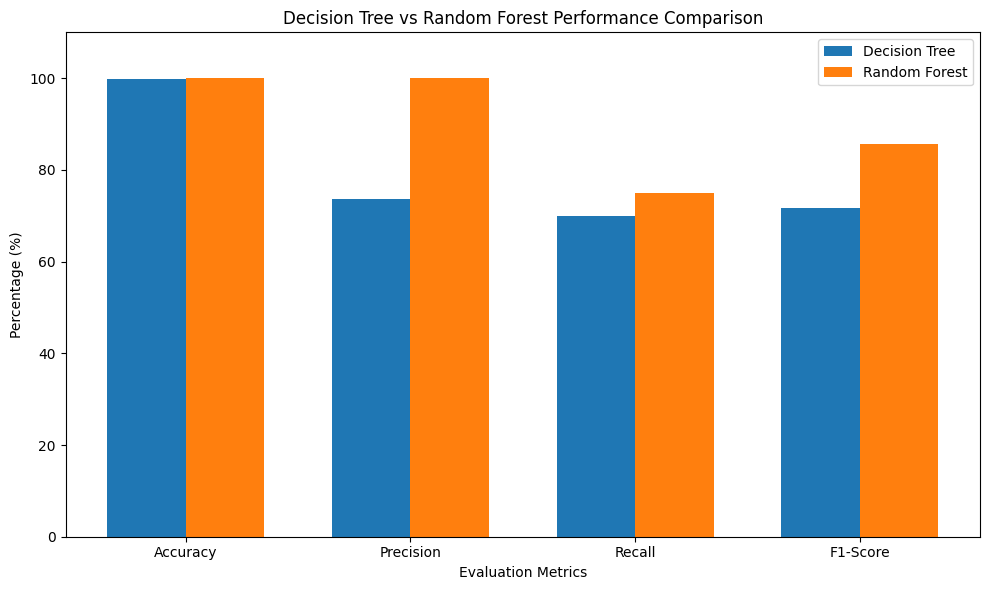

In [17]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

dt_values = [dt_accuracy, dt_precision, dt_recall, dt_f1]
rf_values = [rf_accuracy, rf_precision, rf_recall, rf_f1]
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, dt_values, width, label="Decision Tree")
plt.bar(x + width/2, rf_values, width, label="Random Forest")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Percentage (%)")
plt.title("Decision Tree vs Random Forest Performance Comparison")
plt.xticks(x, metrics)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()